# Biodiesel figure reproduction on `biodiesel_v2.npz`

- **Data:** `chemkan/data/generated/biodiesel_v2.npz` (sha256 `c79afbfb…`): released-code reaction order, the authors' initial conditions (`diesel_u0_samples.txt`, rows 1-20 train, 21-30 test), additive species-max noise at 0/1/2/3/5/7/10/15 % (authors' clarification, email B5).
- **Protocol:** the runs of `chemkan/scripts/author_repo_match/run_figures.py`, seed 0. Fig. 5: ChemKAN 156 (H = 4, batched FSA) and DeepONet 308 at every noise level, 10,000 epochs. Fig. 4: noise-free ChemKAN H = 2, 3, 4, 9, 11 (5,000 epochs) and DeepONet 78-456 (50,000 epochs). Sizes and sources: `docs/authors_materials.md` §3.
- **DeepONet shown: tanh, Adam lr 1e-2 (behaviour-matching ablation).** The reference DeepONet settings (Lu et al. / DeepXDE: truncated Glorot-normal weights, zero biases; branch final layer linear, trunk final layer activated), raw physical time in the trunk, author-global normalized branch inputs and targets, mean-MSE objective, seed 0 -- with the activation changed from ReLU to tanh and Adam lr 1e-2 (the released ChemKAN example's lr) instead of 1e-3 (`results/experiments/biodiesel/author_repo_match/figures_tanh_r1_lr1e-2/`). The paper states neither the DeepONet activation nor its learning rate, so this is an ablation, not a confirmed author setting. Its losses are re-scored in the same train-only normalization as the ChemKAN runs.
- **Why these settings** (0 % noise, 10 paired seeds, final training MSE): ReLU with the reference settings (R1) plateaus near 1e-3 (median 2.4e-3; 0/30 seeds reach 1e-4); tanh at lr 1e-3 reaches a median 8.9e-5 but converges slowly early (1.3e-3 at epoch 2,500); tanh at lr 1e-2 reaches a median 3.3e-5 (2.4e-4 at epoch 2,500), close to the paper's Fig. 5B. Sources: `results/experiments/biodiesel/deeponet_diagnostics/tanh_R1/summary.txt`, `tanh_R1_lr1e-2/summary.txt`. Other variants: `author_runs.DEEPONET_VARIANT = "tanh_r1"` (lr 1e-3) or `"relu_legacy"` (earlier ReLU runs).
- **Loss convention:** time-averaged MSE (divided by the number of time points), as the released code (`Flux.mse`: mean over species and the 30 times). Eq. 18 = 30 × this.
- **Single seed per configuration:** read differences between runs accordingly.

Everything below is computed by `chemkan/scripts/figures/` (`author_runs.py`, the `make_author_figure` functions, `author_paper_table.py`); this notebook only calls them.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts" / "figures"))

import pandas as pd
from IPython.display import Markdown, display

import author_runs as ar
import author_paper_table as table
import fig03_biodiesel_trajectories as fig03
import fig04_biodiesel_scaling as fig04
import fig05_biodiesel_loss as fig05b
import fig05_biodiesel_noise as fig05a
import fig06_biodiesel_profiles as fig06

print("data:", ar.DATA.relative_to(ar.ROOT), "sha256", ar.DATA_SHA256)

data: chemkan/data/generated/biodiesel_v2.npz sha256 c79afbfbbee863f50704985aaf658931d8e989f8086d528f97dfd6d680ca7b31


## Verification of the figure runs

Each run: `checkpoint_final.pt`, the full epoch count, finite losses, `biodiesel_v2.npz` with the expected sha256, and the settings planned by `run_figures.py`. Losses are those of the last logged epoch (time-averaged).

In [2]:
rows, problems = ar.verify()
display(pd.DataFrame(rows).set_index("run"))
print(f"{len(rows)} runs, {len(problems)} with problems")
for p in problems:
    print("PROBLEM", p)

,model,status,epochs,parameters,train_final,test_clean_final,test_noisy_final
run,,,,,,,
fig05_chemkan_noise00,chemkan,ok,10000,156,0.000071,0.000287,NaN
fig05_deeponet_noise00,deeponet,ok,10000,308,0.000036,0.000246,0.000246
fig05_chemkan_noise01,chemkan,ok,10000,156,0.000113,0.000285,0.000325
fig05_deeponet_noise01,deeponet,ok,10000,308,0.000077,0.000238,0.000282
fig05_chemkan_noise02,chemkan,ok,10000,156,0.000250,0.000300,0.000450
fig05_deeponet_noise02,deeponet,ok,10000,308,0.000212,0.000228,0.000387
fig05_chemkan_noise03,chemkan,ok,10000,156,0.000452,0.000243,0.000650
fig05_deeponet_noise03,deeponet,ok,10000,308,0.000409,0.000245,0.000622
fig05_chemkan_noise05,chemkan,ok,10000,156,0.001118,0.000260,0.001196


27 runs, 0 with problems


## Fig. 3: test row 24 at 0 / 5 / 10 / 15 % training noise

The ChemKAN trained at each noise level, on the test condition TG 1.941, ROH 1.433, T 334.75 K, against the ground truth and that level's noisy test observations.

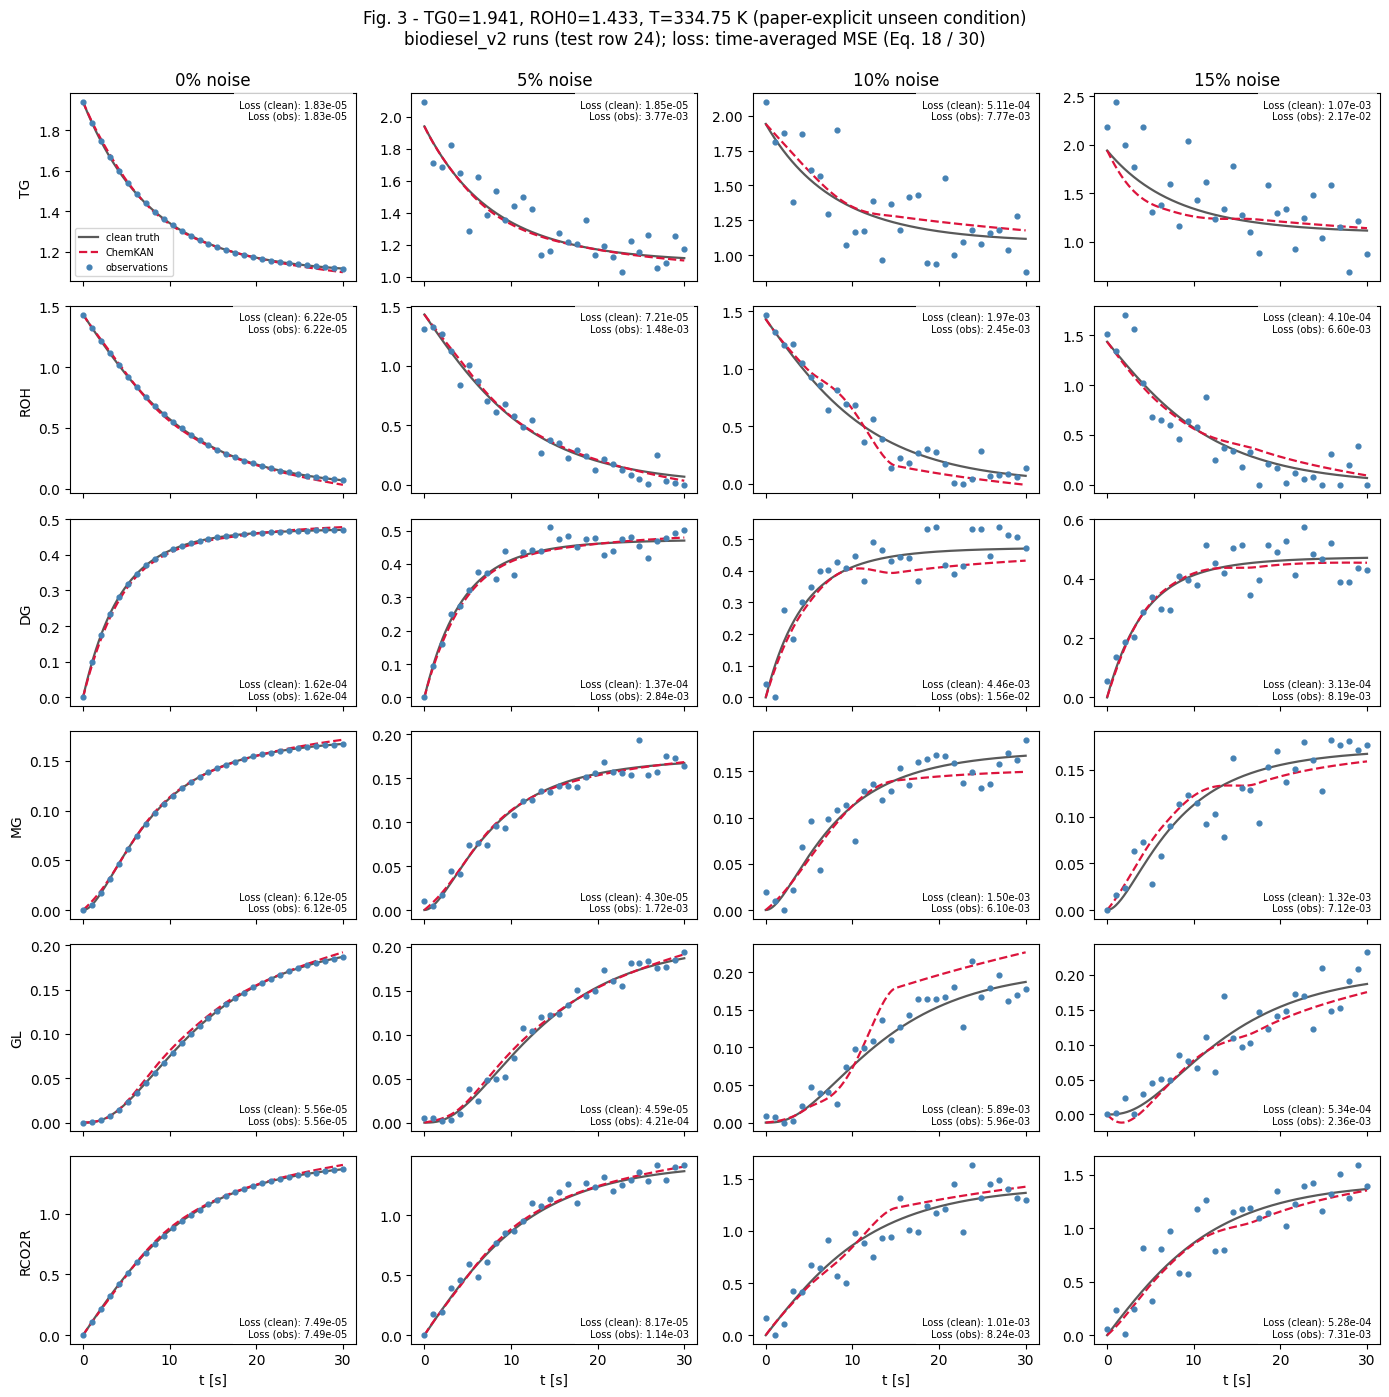

In [3]:
fig, fig3_data = fig03.make_author_figure(show=True)

## Fig. 4: neural scaling (noise-free)

Final-checkpoint training and testing loss against parameter count, with log-log fits that exclude the last ChemKAN and the last two DeepONet points (paper Sec. III A 2).

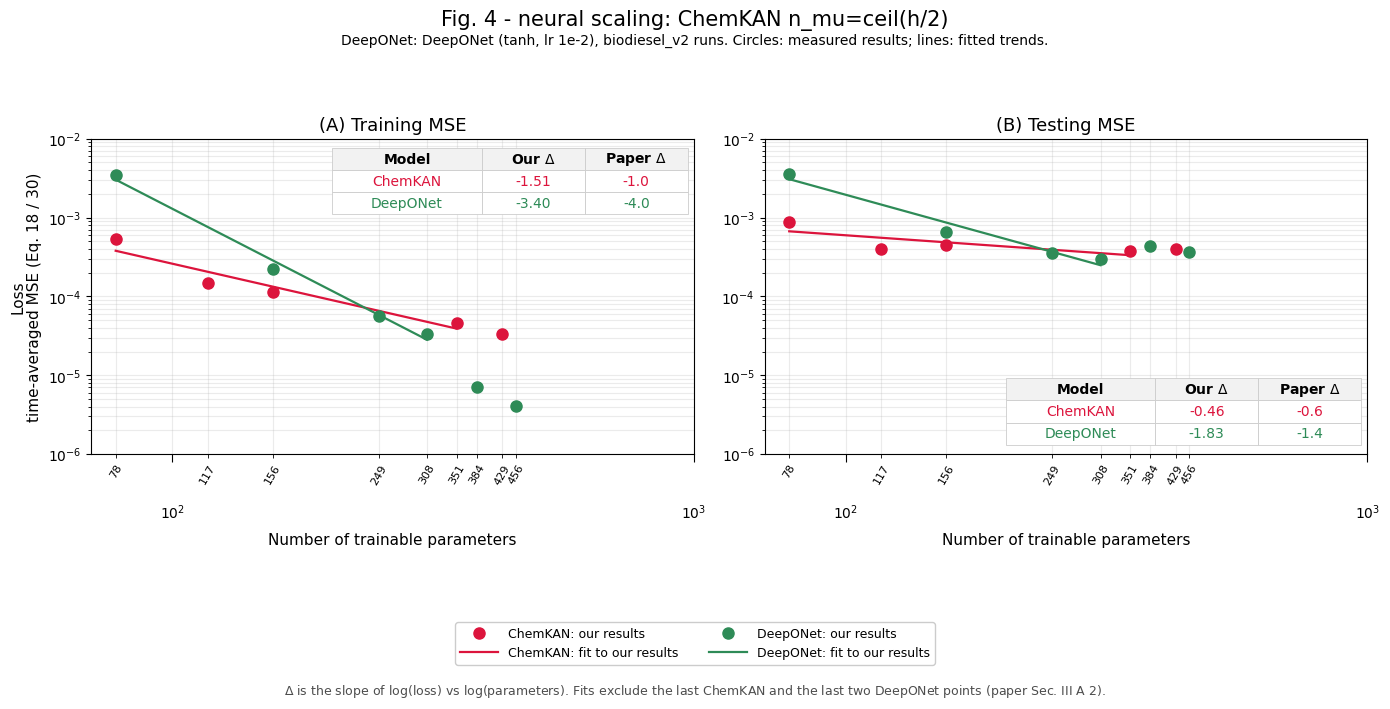

In [4]:
fig, scaling = fig04.make_author_figure(show=True)

## Fig. 5A: converged losses vs noise

Final checkpoints after 10,000 epochs (the paper's "converged" losses): training (noisy targets), noisy testing and noise-free testing loss.

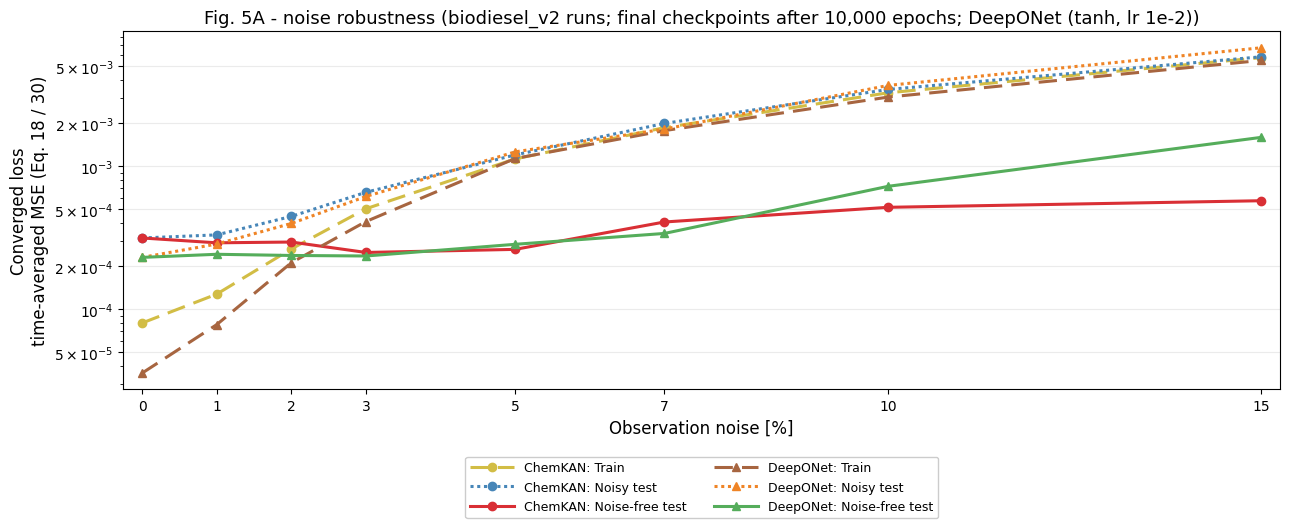

In [5]:
fig, noise = fig05a.make_author_figure(show=True)

## Fig. 5B: loss histories at 0, 2, 7, 15 % noise

Training and noise-free testing loss per epoch, both models.

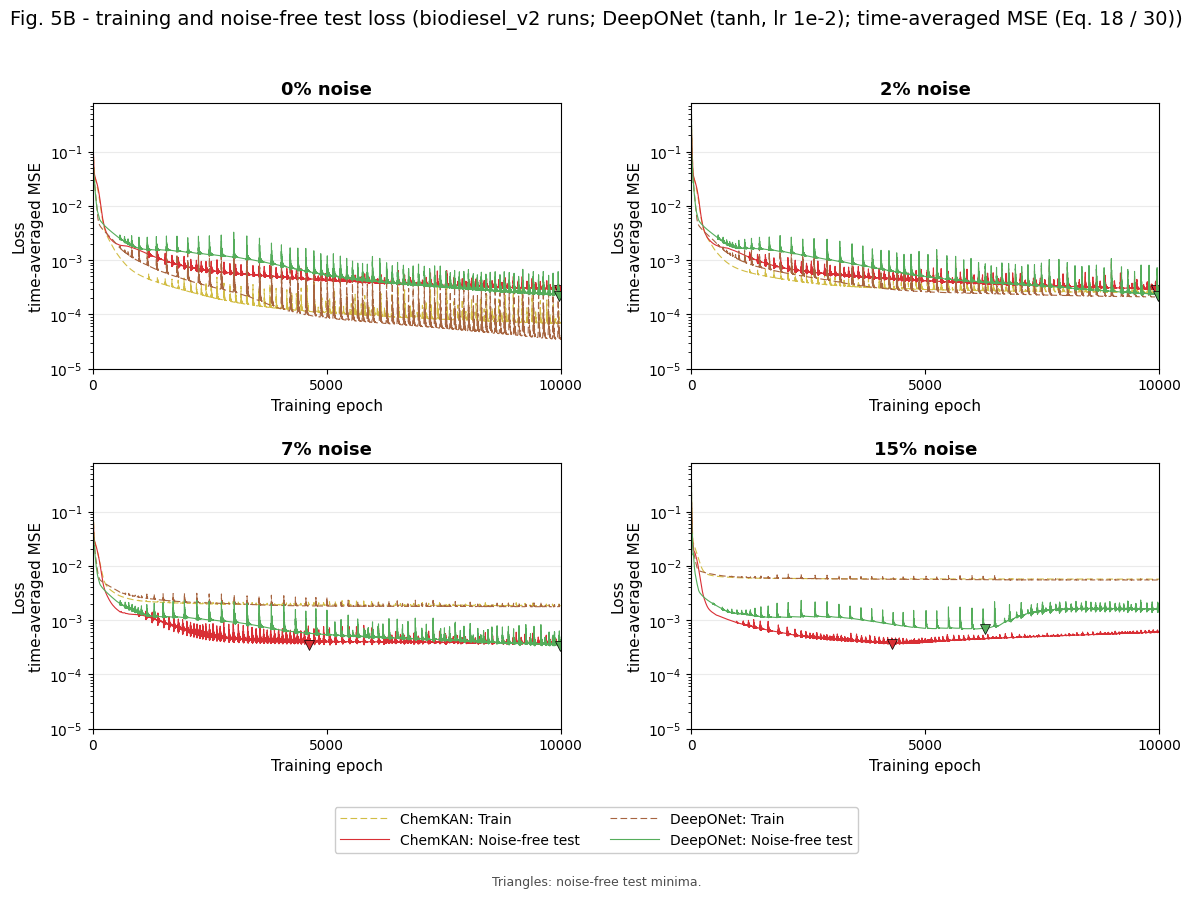

In [6]:
fig = fig05b.make_author_figure(show=True)

## Fig. 6: 15 % noise reconstructions

Both models on test row 24, trained at 15 % noise, with their noise-free MSE on this trajectory.

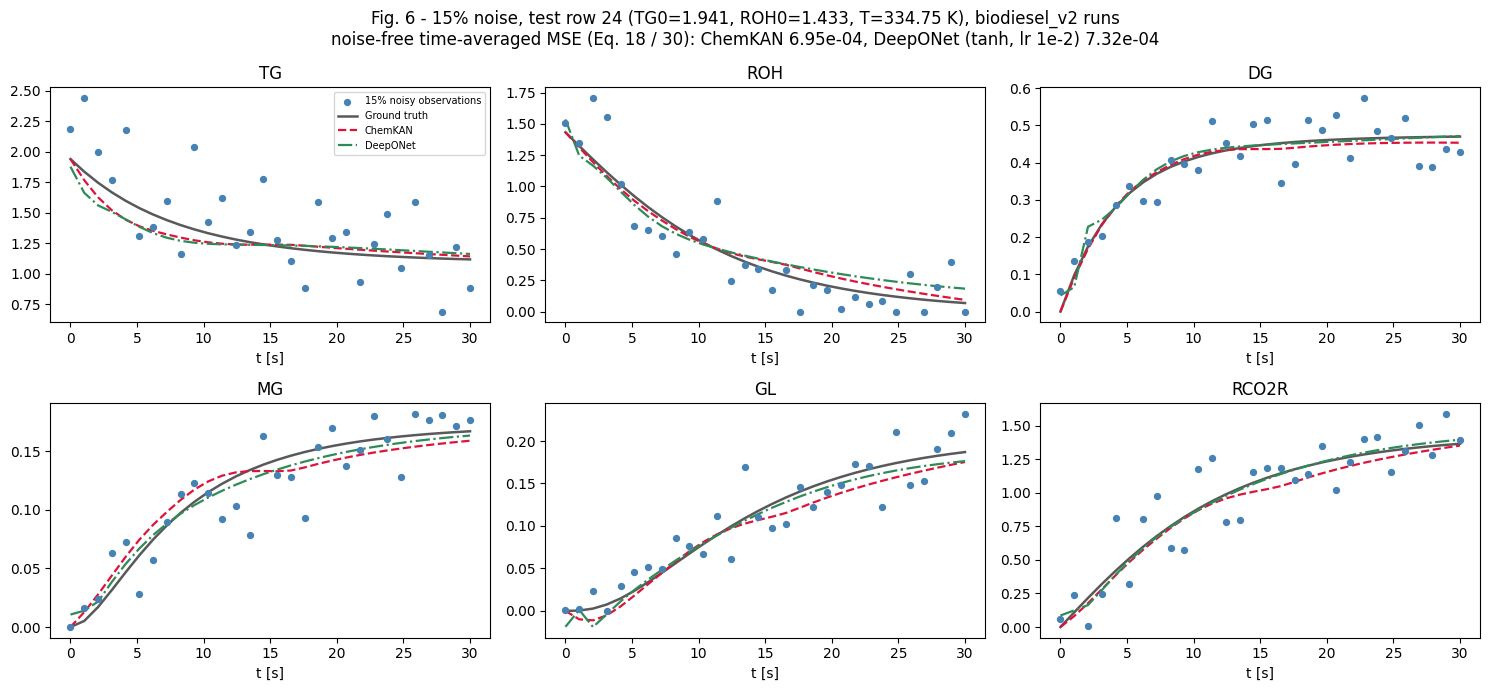

In [7]:
fig, profile = fig06.make_author_figure(show=True)

## Comparison with the paper

Only numbers stated in the paper's text; section cited per row. Ours in the time-averaged convention unless a row gives Eq. 18.

In [8]:
display(Markdown(table.markdown(table.comparison(scaling, noise))))

| quantity | paper (section) | ours | how ours was computed |
|---|---|---|---|
| ChemKAN neural-scaling order, training | 1.0 (Sec. III A 2) | 1.51 | -(slope) of a log-log least-squares fit of final-checkpoint training MSE vs parameters, H = 2, 3, 4, 9 (last point, H = 11, excluded) |
| ChemKAN neural-scaling order, testing | 0.6 (Sec. III A 2) | 0.464 | same fit on the final-checkpoint noise-free testing MSE |
| ChemKAN error at the smallest size | ~1e-4 (72 parameters in the text; 78 per email B2) (Sec. III A 2) | train 0.000528, test 0.000887 (Eq. 18: 0.0158, 0.0266) | final checkpoint of the 78-parameter run (H = 2) |
| DeepONet training loss below ChemKAN's above ~200 parameters | yes (Sec. III A 2) | no: DeepONet 249: 5.59e-05, 308: 3.32e-05, 384: 7.1e-06, 456: 4.02e-06; ChemKAN 351: 4.6e-05, 429: 3.33e-05 | final-checkpoint training MSE of every run above 200 parameters |
| ChemKAN training-MSE increase, 0 -> 1 % noise | 3.78e-5 (Sec. III A 3) | time-averaged 4.73e-05; Eq. 18 0.00142 (noise floor: 4.46e-05; Eq. 18 0.00134) | difference of converged training MSE (final checkpoint after 10,000 epochs); noise floor = MSE between noisy and clean training targets, the increase a perfect model would show |
| ChemKAN training-MSE increase, 0 -> 5 % noise | 9.45e-4 expected (25 x 3.78e-5); 9.64e-4 observed (Sec. III A 3) | time-averaged 0.00104; Eq. 18 0.0312 (noise floor: 0.00108; Eq. 18 0.0325) | as above, at 5 % |
| ChemKAN noise-free testing MSE, 15 % / 0 % | ~2x (Sec. III A 3) | 1.82x | ratio of converged noise-free testing MSE (final checkpoints) |
| DeepONet noise-free testing MSE, 15 % / 0 % | ~5x (Sec. III A 3) | 6.90x | same, DeepONet 308 |
| noise-free testing MSE at 15 %, DeepONet / ChemKAN | 4.4x (Sec. III A 3) | 2.77x | ratio of the two converged 15 % values |